In [2]:
import json
import pandas as pd

In [3]:
exp = 'opinion_distr_theseus_same' # 'same'
llm = 'gemma3:4b' 
llm2 = 'mistral' if llm == 'llama3' else 'llama3'
min_size = 0.1
h = 1.0
rows = []
with open(f'results/theseus_{exp}_{llm}_0_PAH-min{min_size}-h{h}.jsonl') as f:
    init =  json.loads(f.readline())
    for i, l in enumerate(f):
        row = json.loads(l)
        rows.append(row)
        

FileNotFoundError: [Errno 2] No such file or directory: 'results/theseus_opinion_distr_theseus_same_gemma3:4b_0_PAH-min0.1-h1.0.jsonl'

results/reverse_theseus_opinion_distr_theseus_same_gemma3:4b_0_PAH-min0.1-h0.0.jsonl
results/reverse_theseus_opinion_distr_theseus_same_gemma3:4b_0_PAH-min0.1-h0.25.jsonl
results/reverse_theseus_opinion_distr_theseus_same_gemma3:4b_0_PAH-min0.1-h0.5.jsonl
results/reverse_theseus_opinion_distr_theseus_same_gemma3:4b_0_PAH-min0.1-h0.75.jsonl
results/reverse_theseus_opinion_distr_theseus_same_gemma3:4b_0_PAH-min0.1-h1.0.jsonl
results/reverse_theseus_opinion_distr_theseus_same_gemma3:4b_0_PAH-min0.3-h0.0.jsonl
results/reverse_theseus_opinion_distr_theseus_same_gemma3:4b_0_PAH-min0.3-h0.25.jsonl
results/reverse_theseus_opinion_distr_theseus_same_gemma3:4b_0_PAH-min0.3-h0.5.jsonl
results/reverse_theseus_opinion_distr_theseus_same_gemma3:4b_0_PAH-min0.3-h0.75.jsonl
results/reverse_theseus_opinion_distr_theseus_same_gemma3:4b_0_PAH-min0.3-h1.0.jsonl
results/reverse_theseus_opinion_distr_theseus_same_gemma3:4b_0_PAH-min0.5-h0.0.jsonl
results/reverse_theseus_opinion_distr_theseus_same_gemma3:4b_

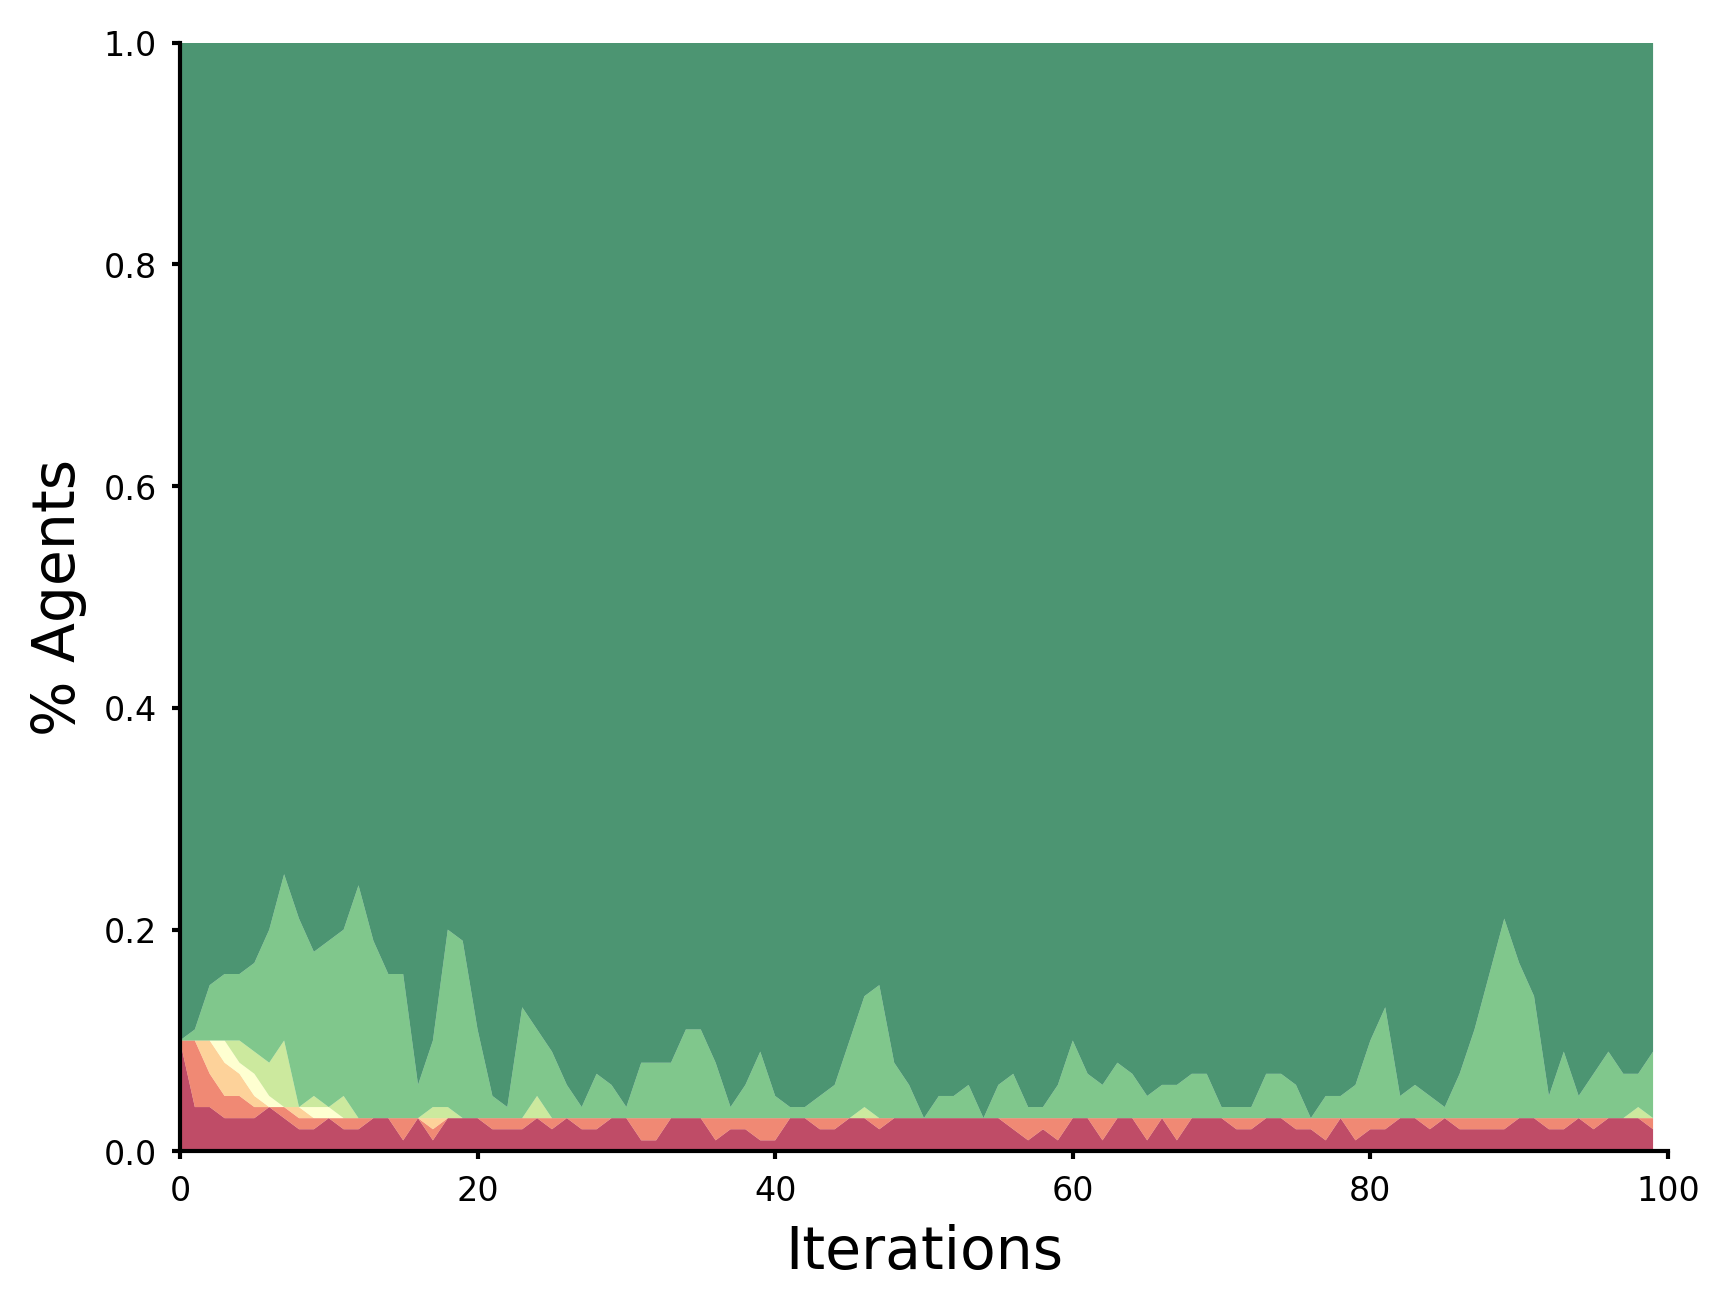

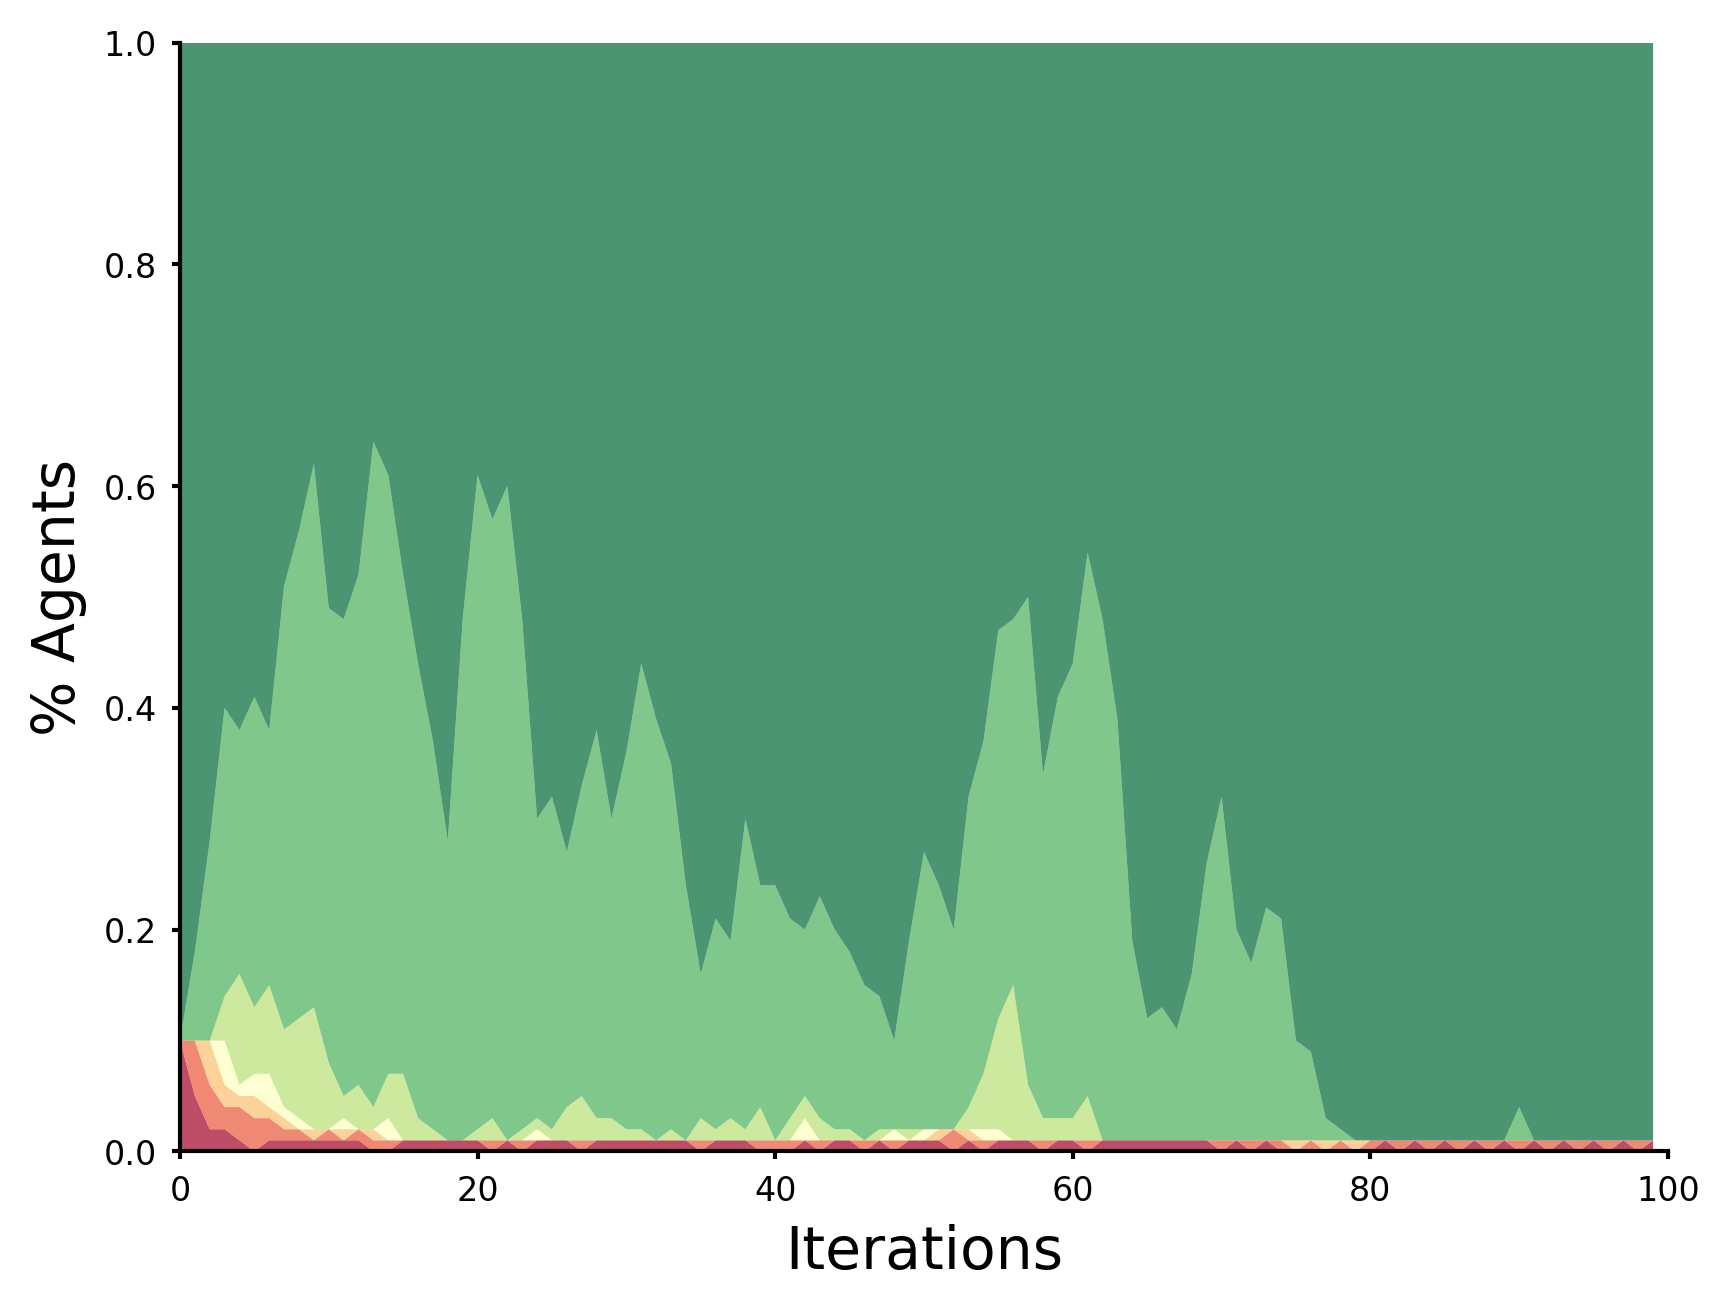

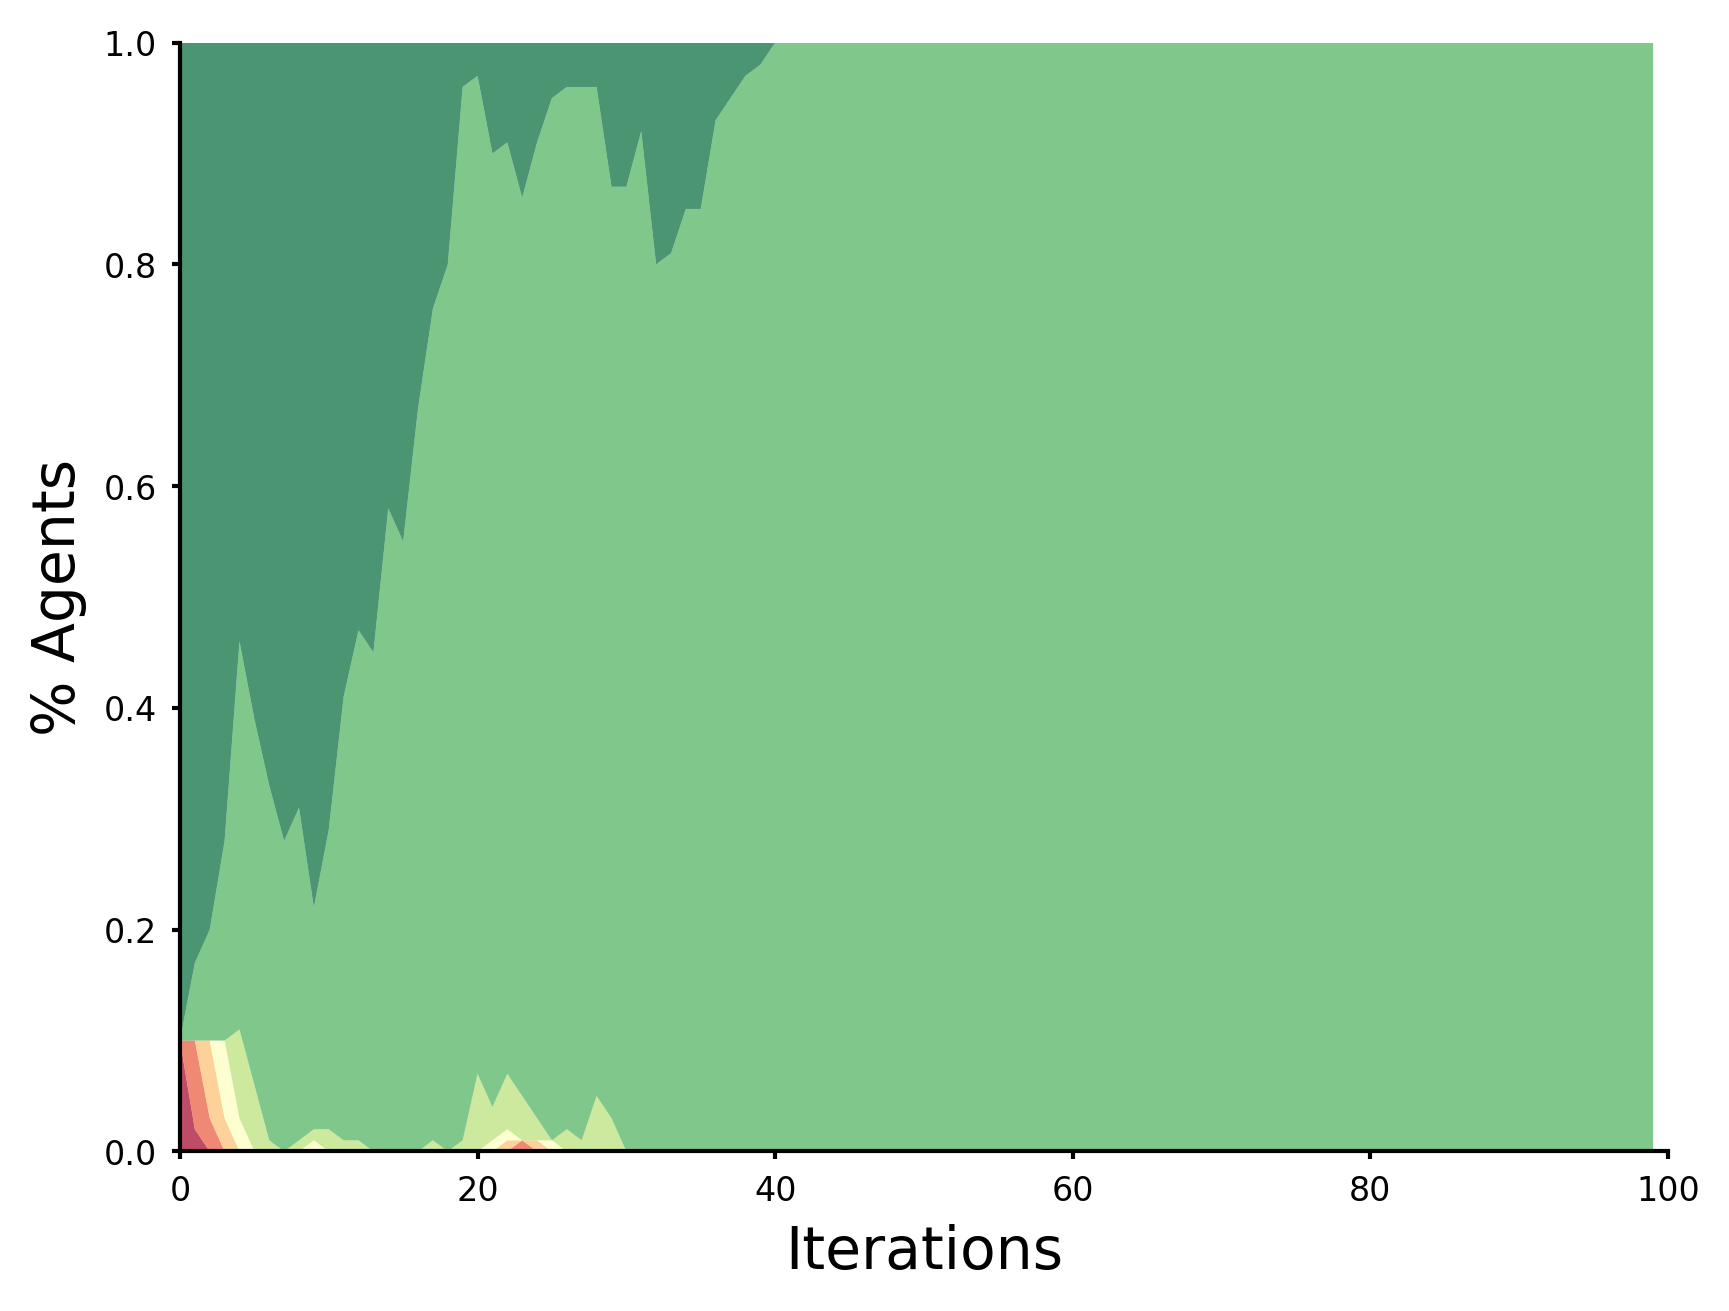

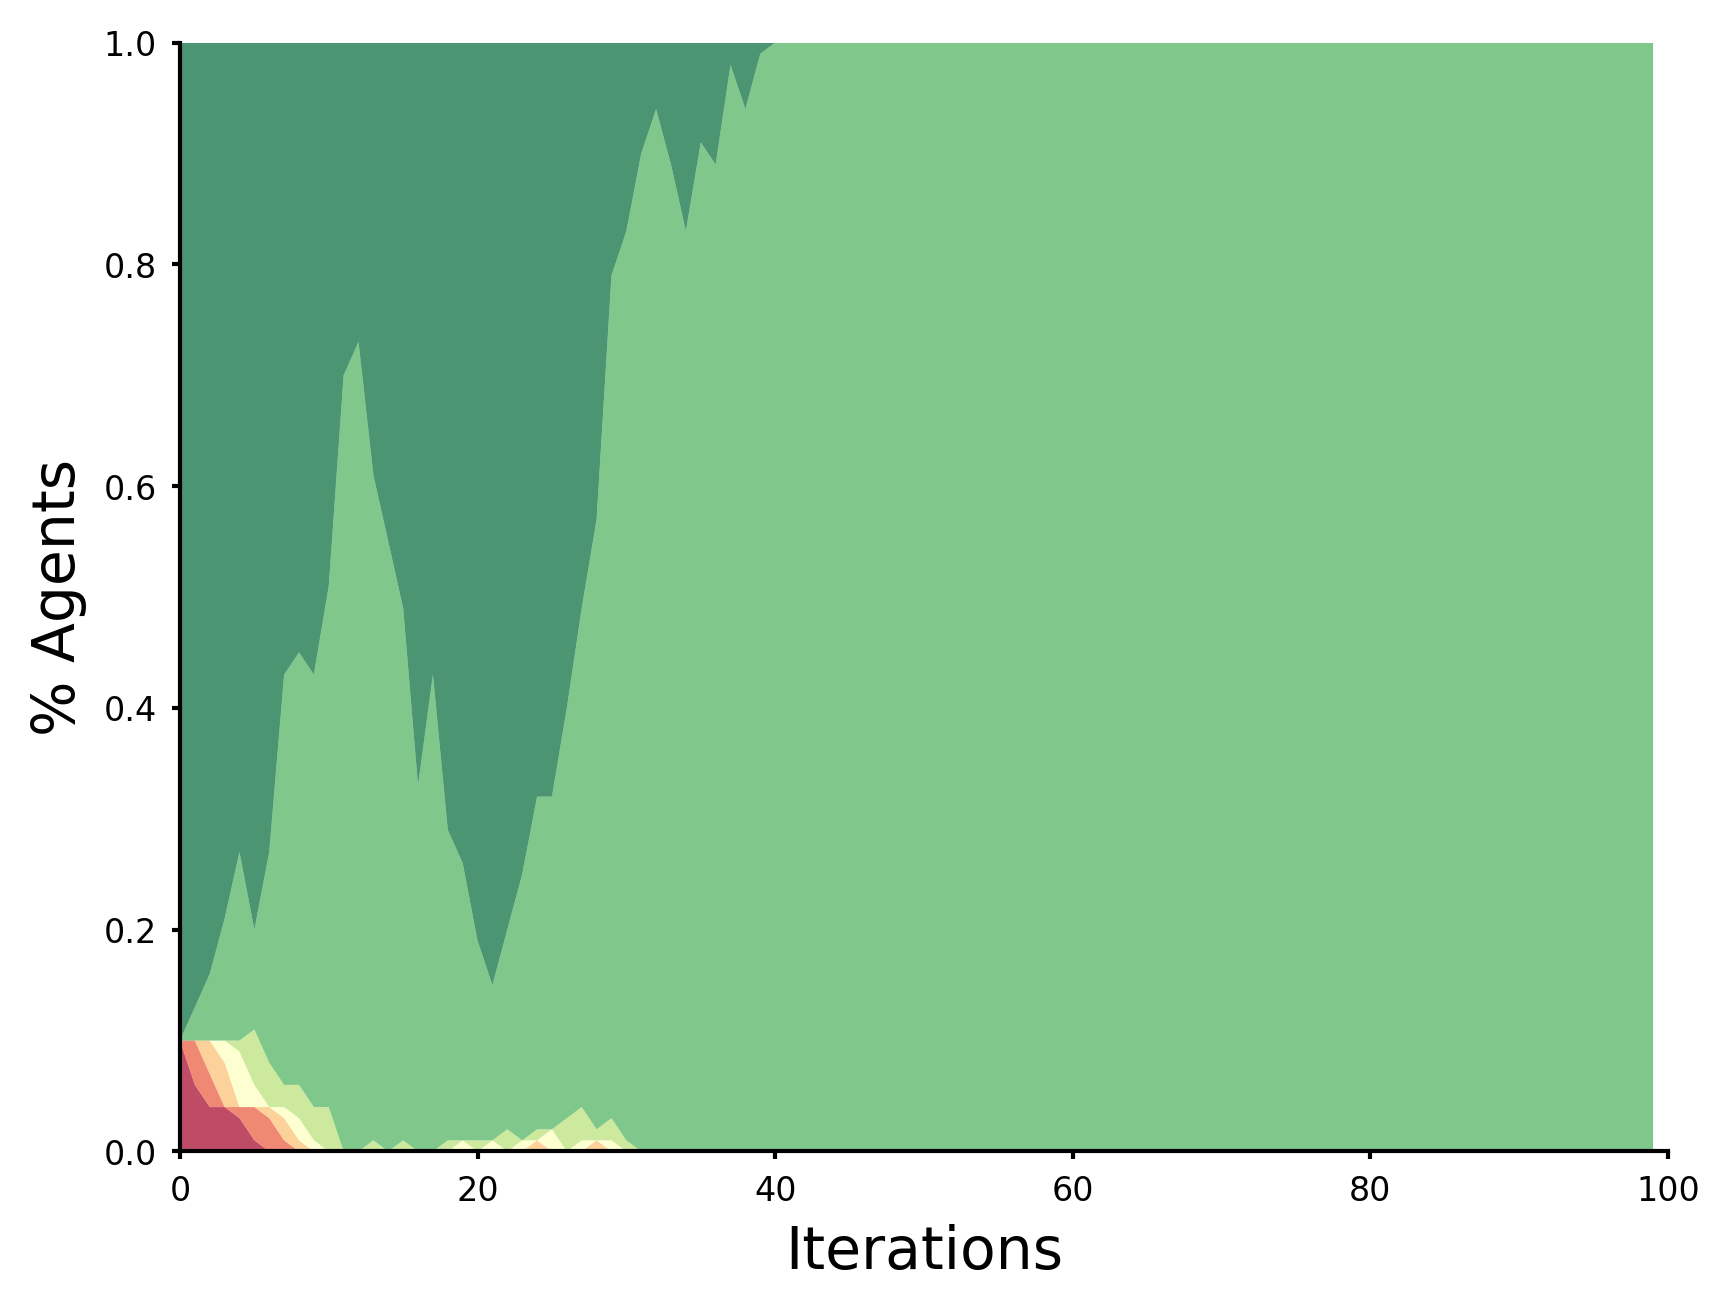

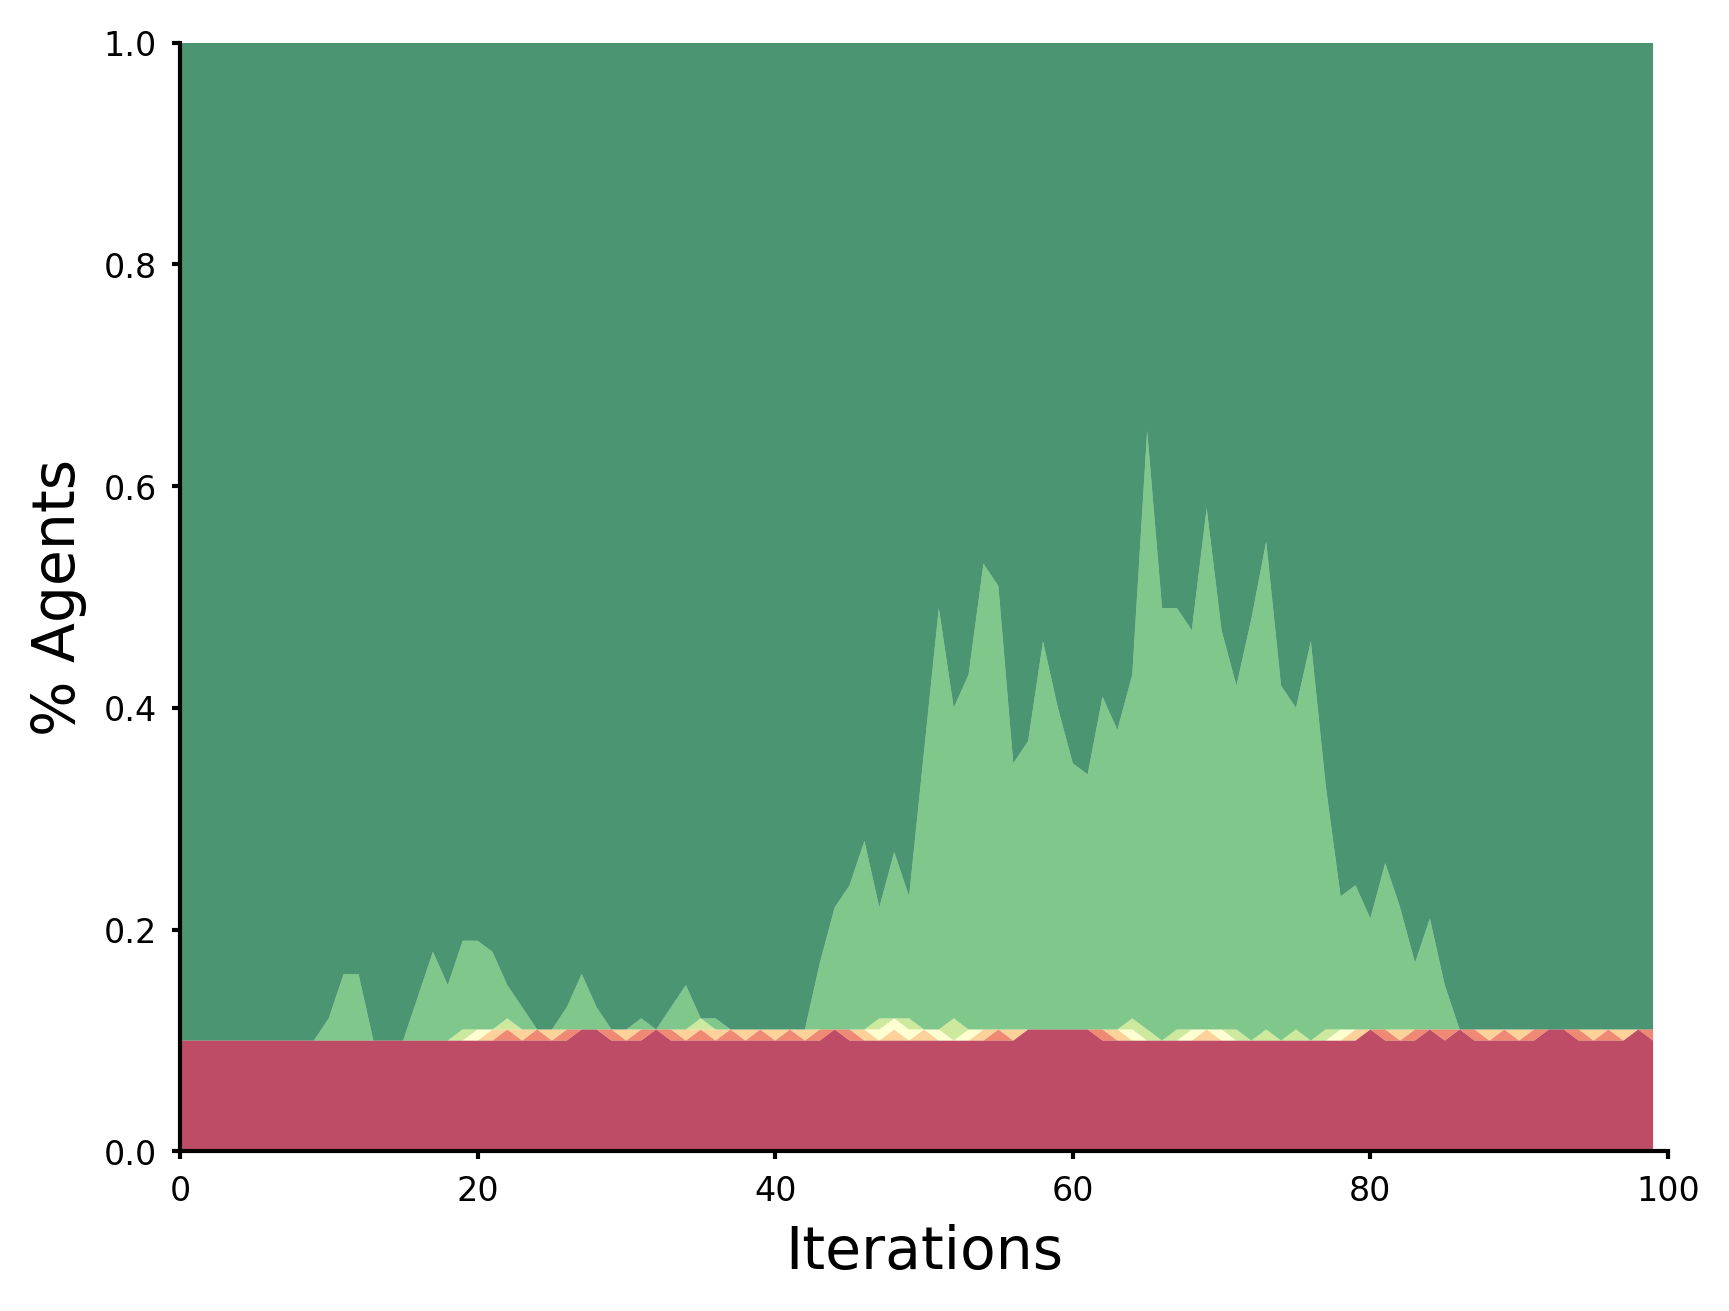

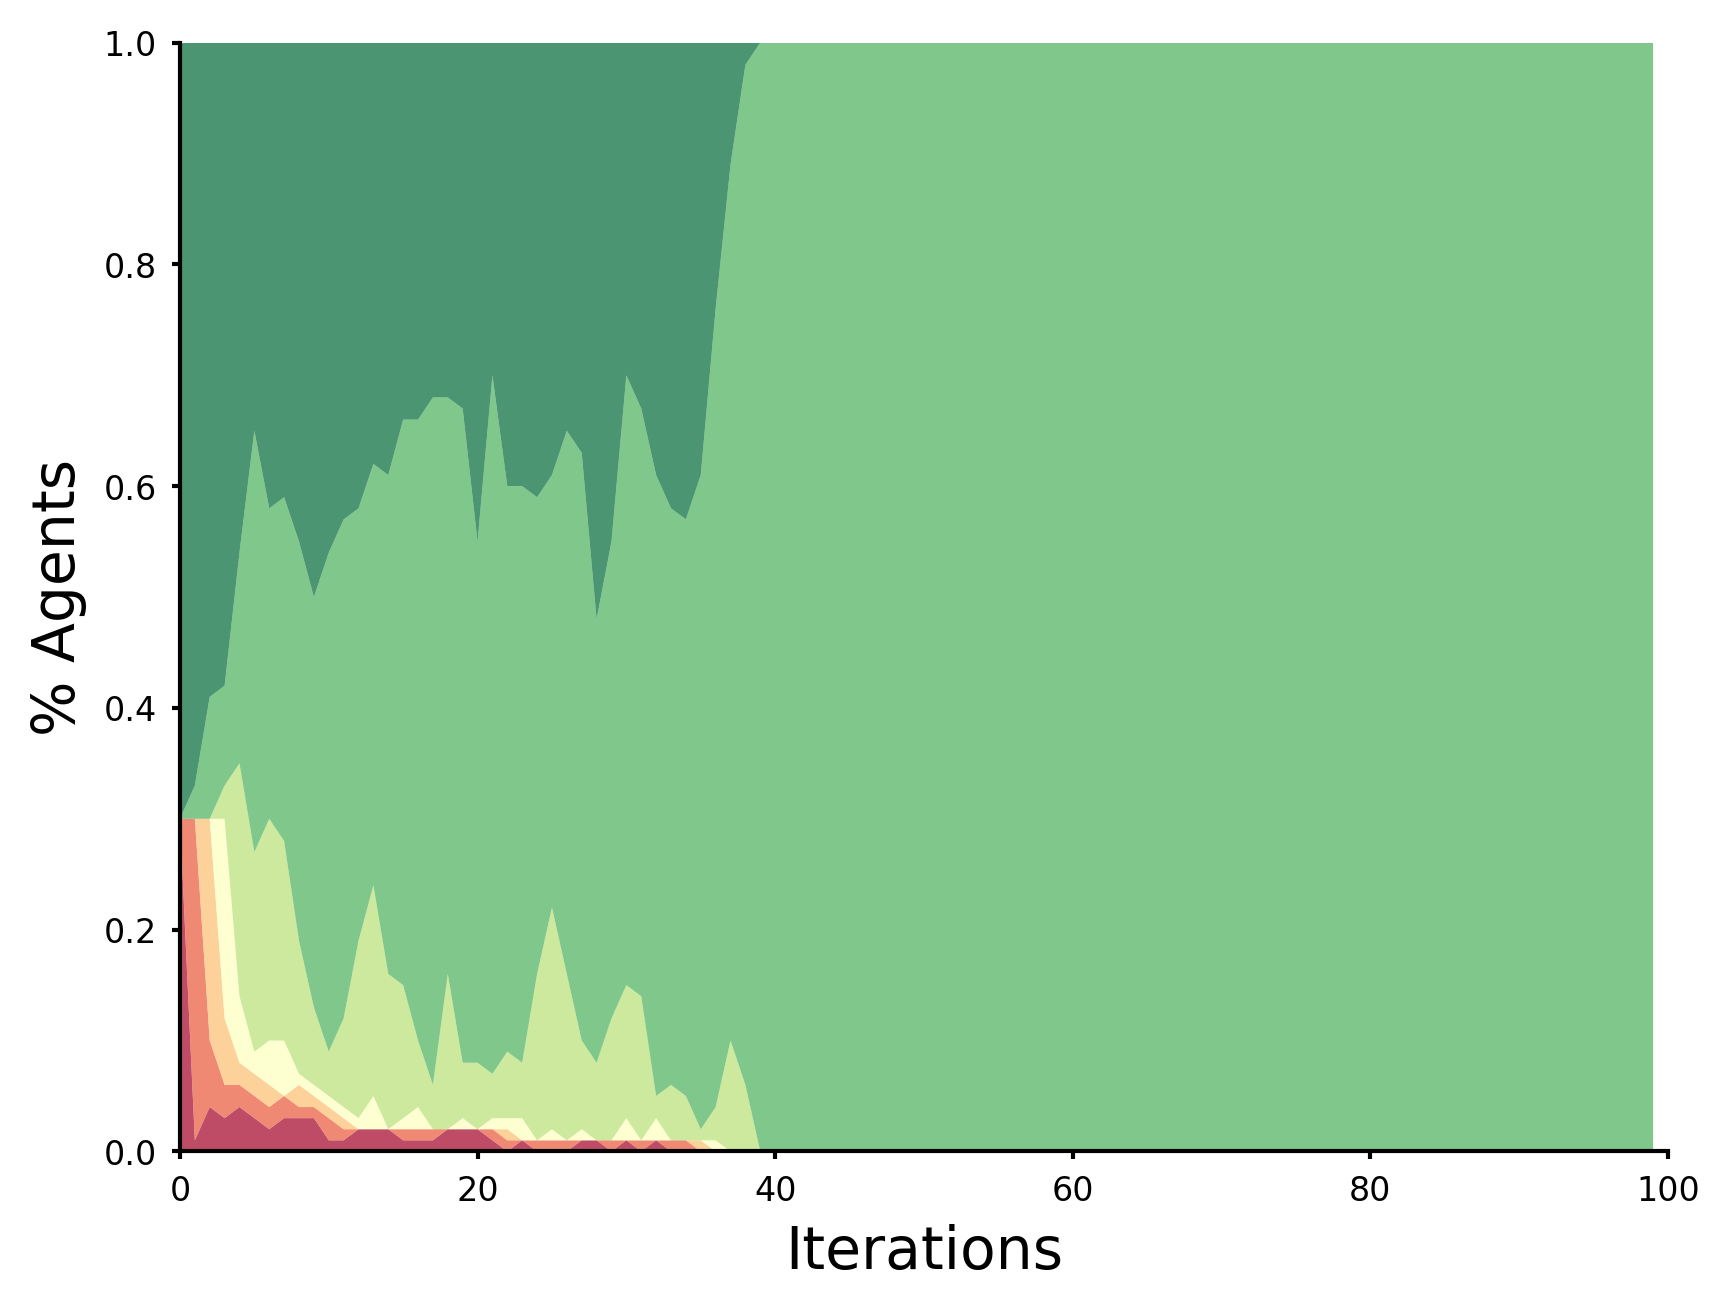

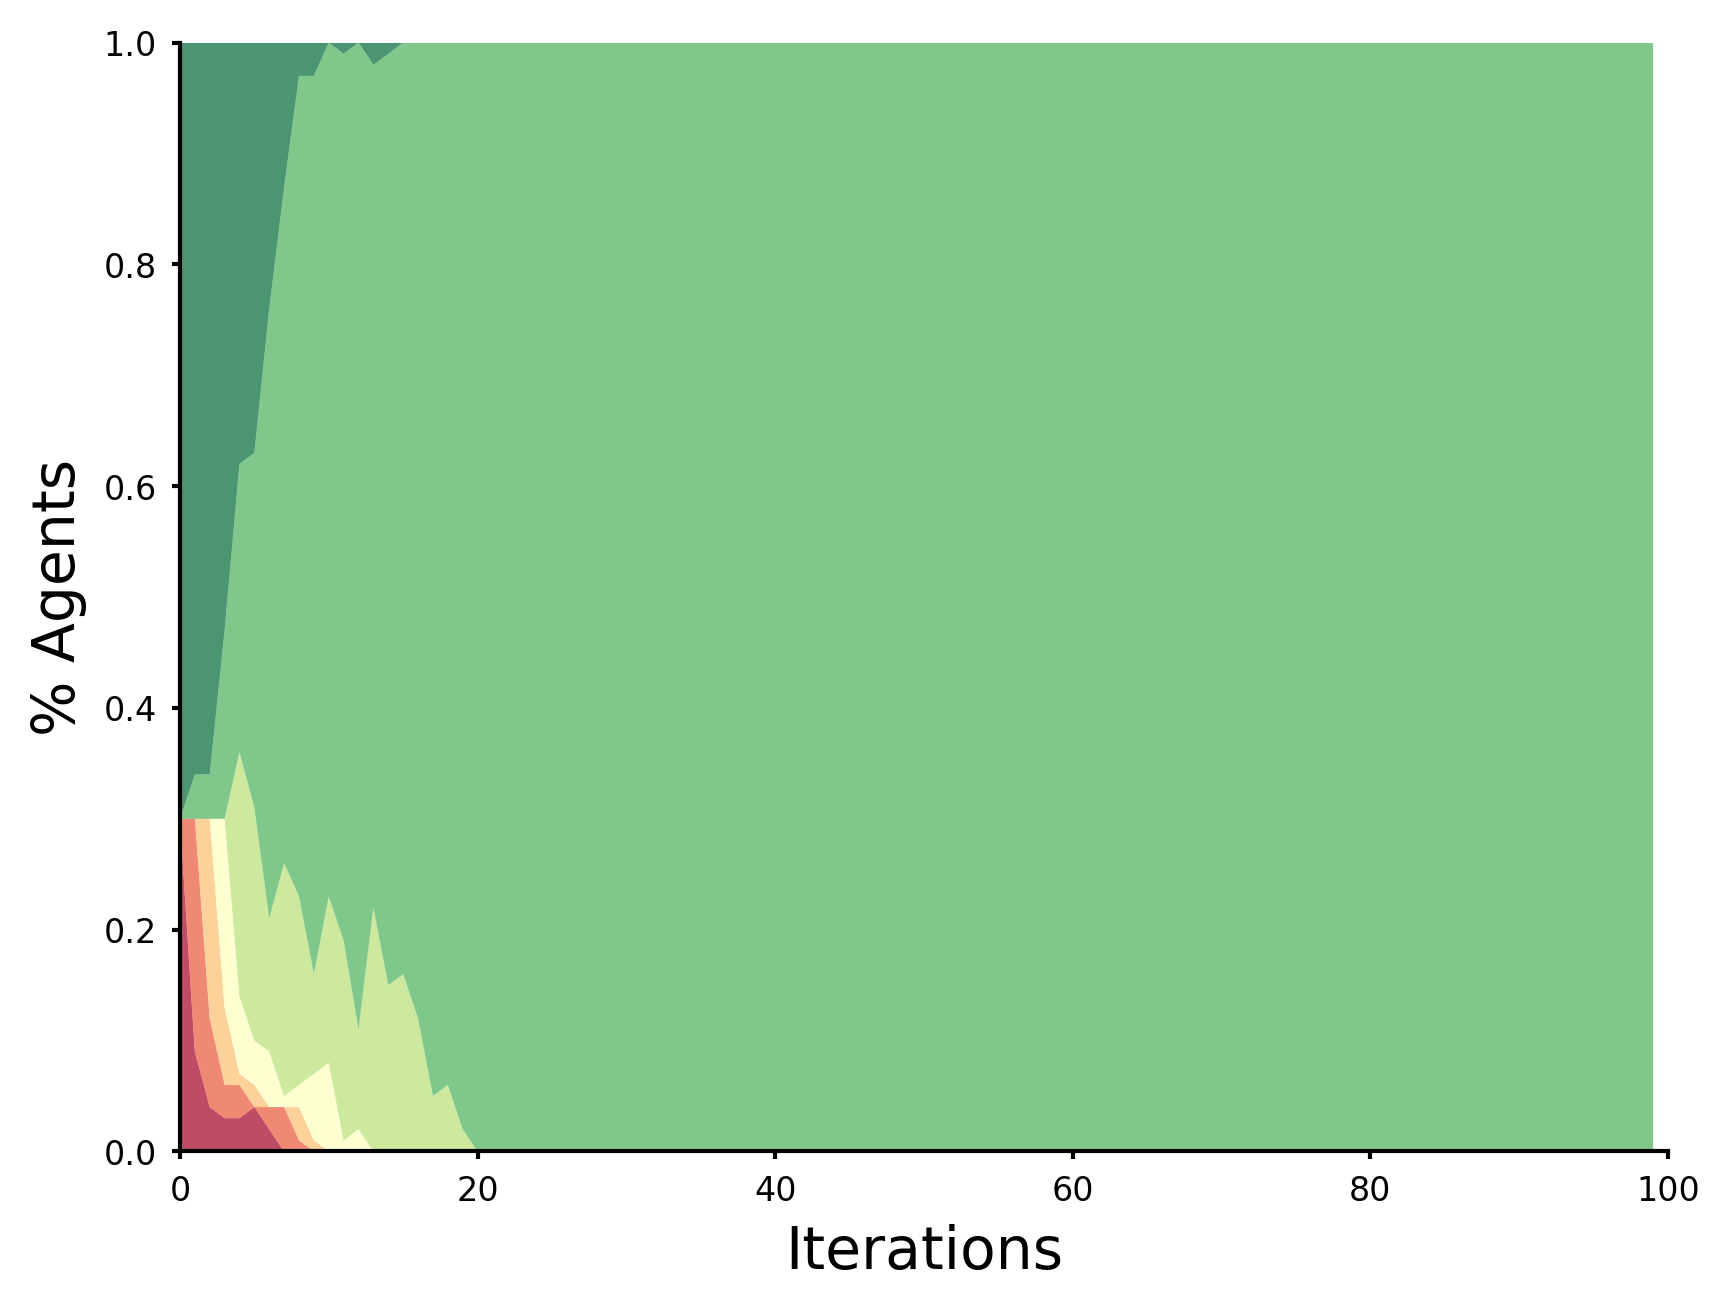

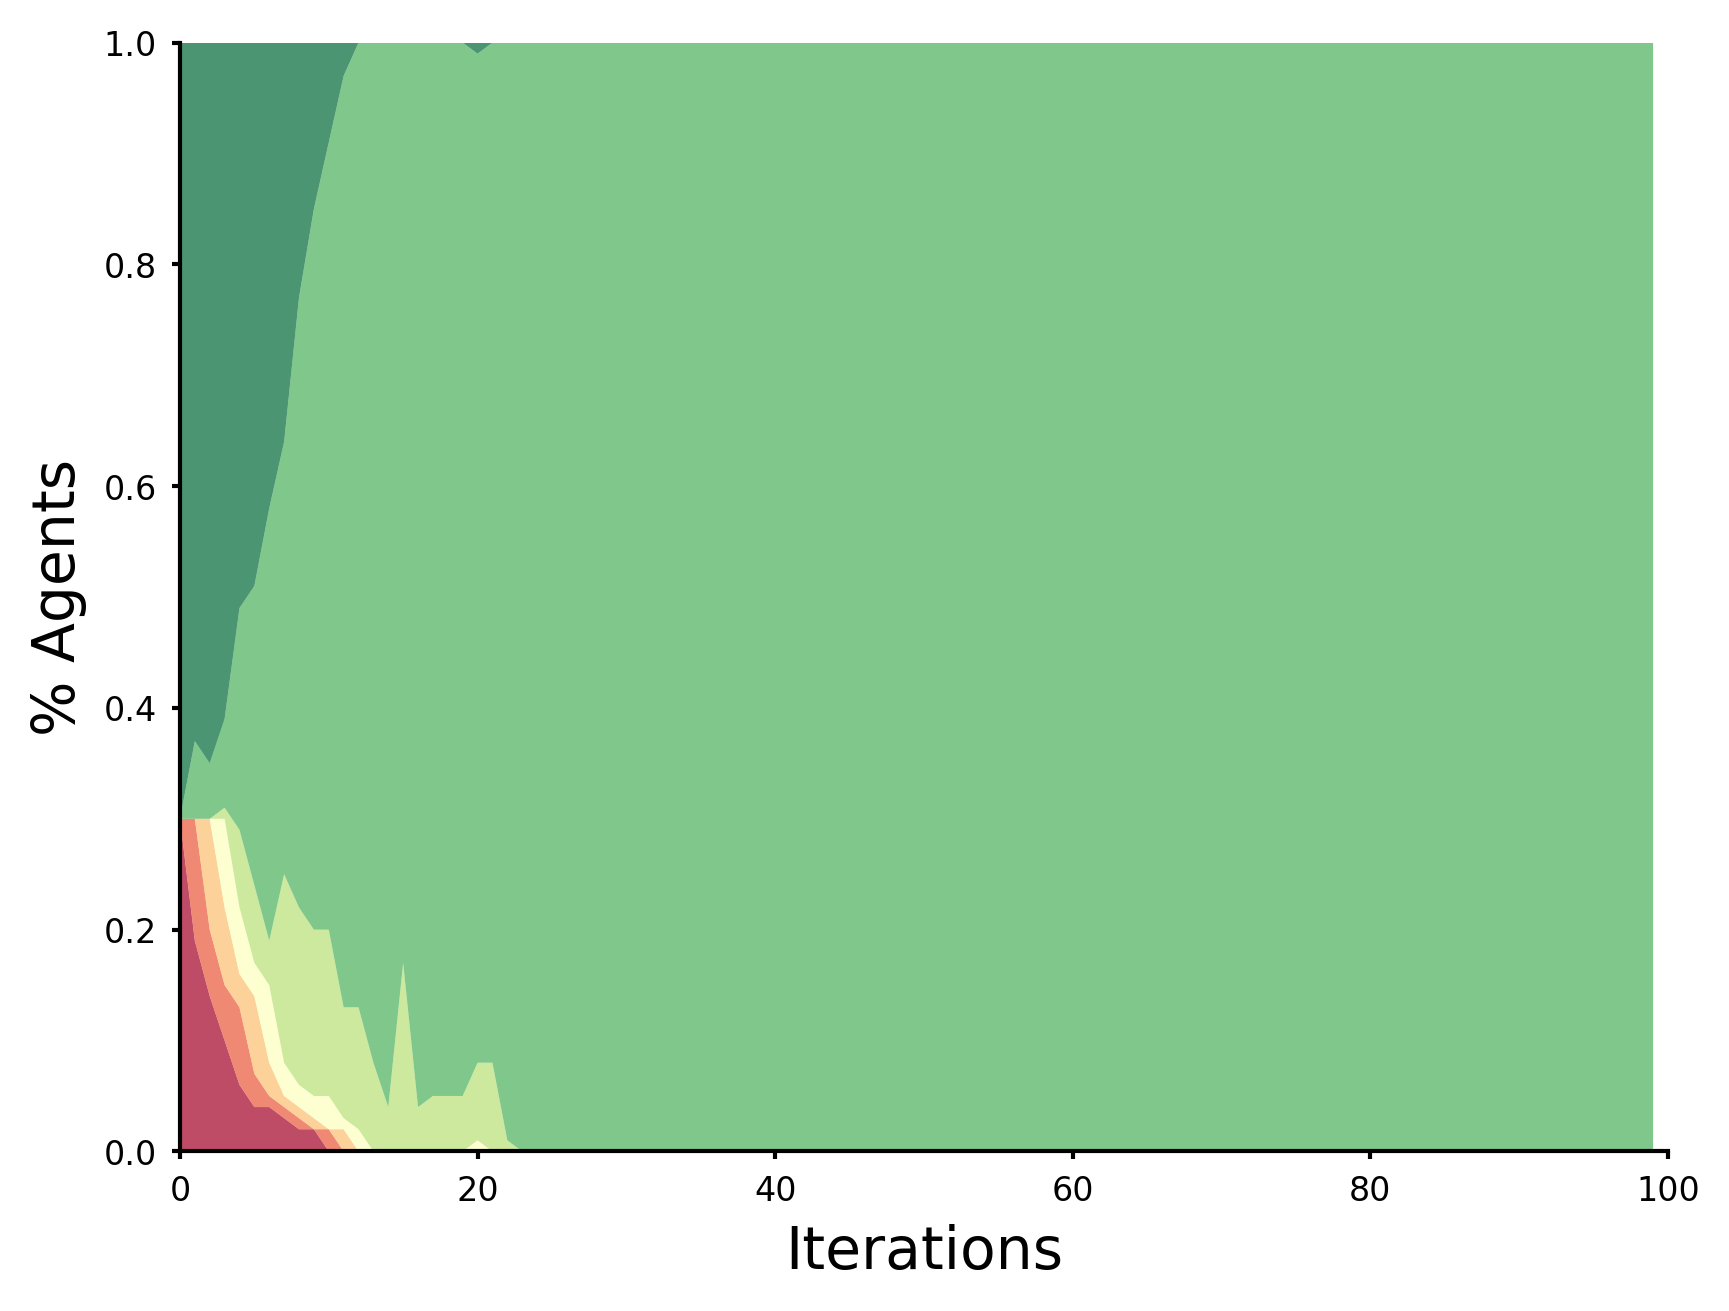

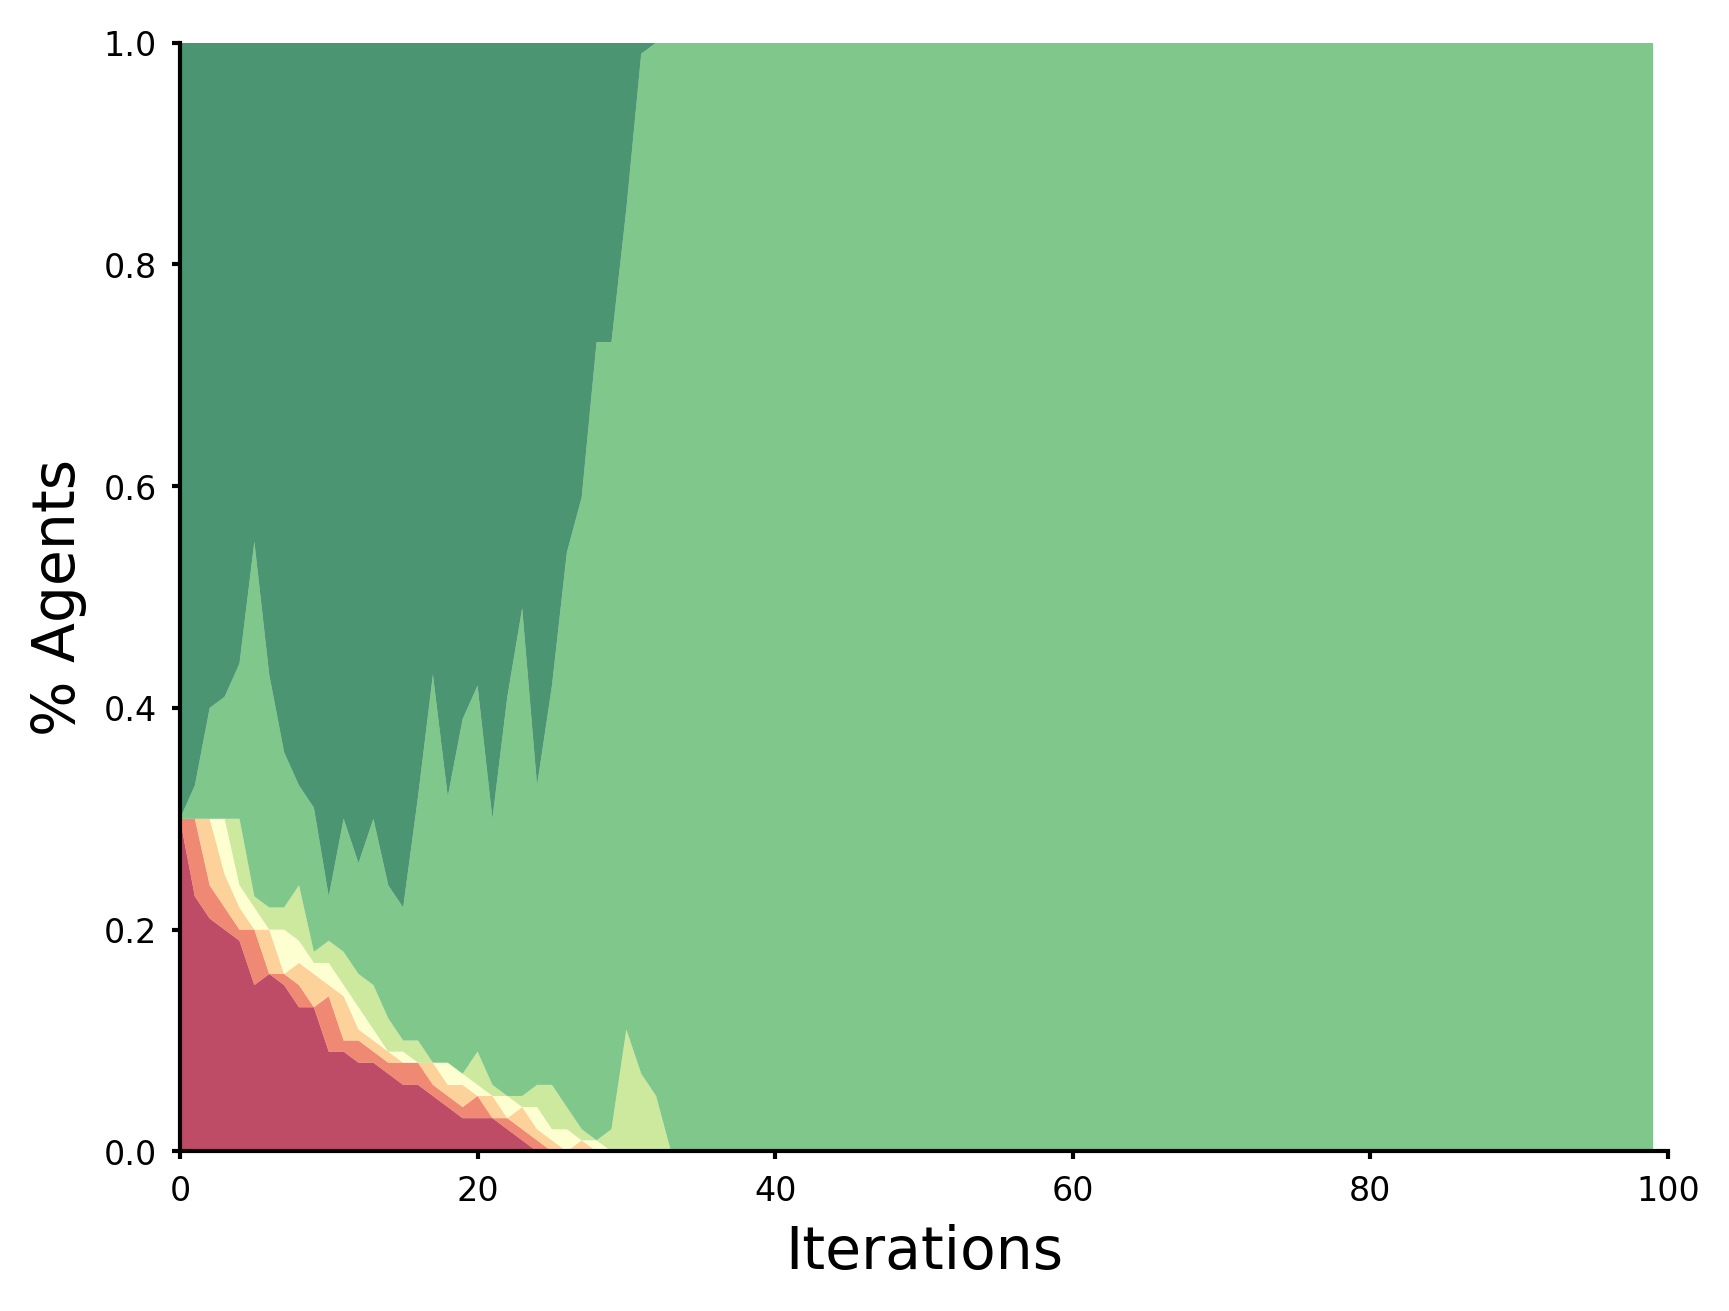

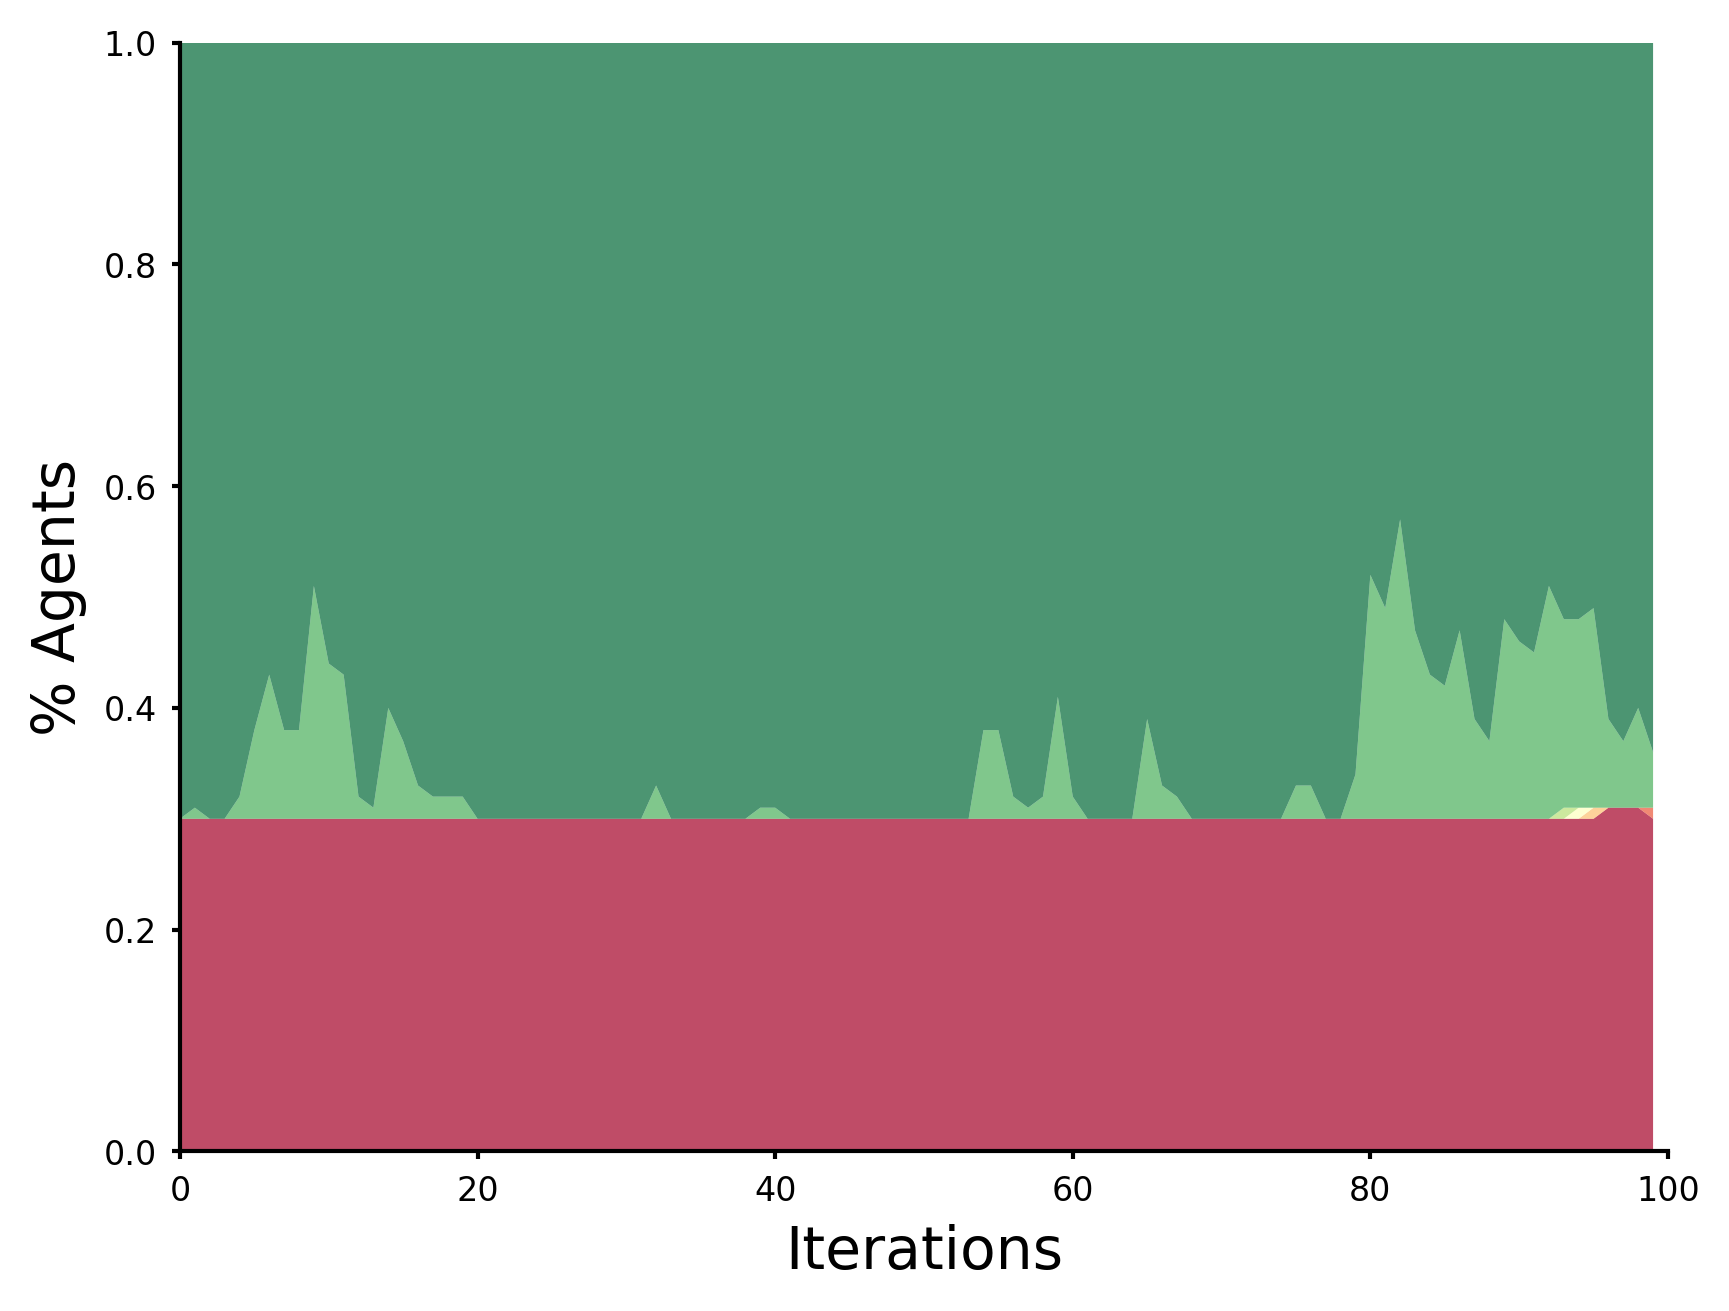

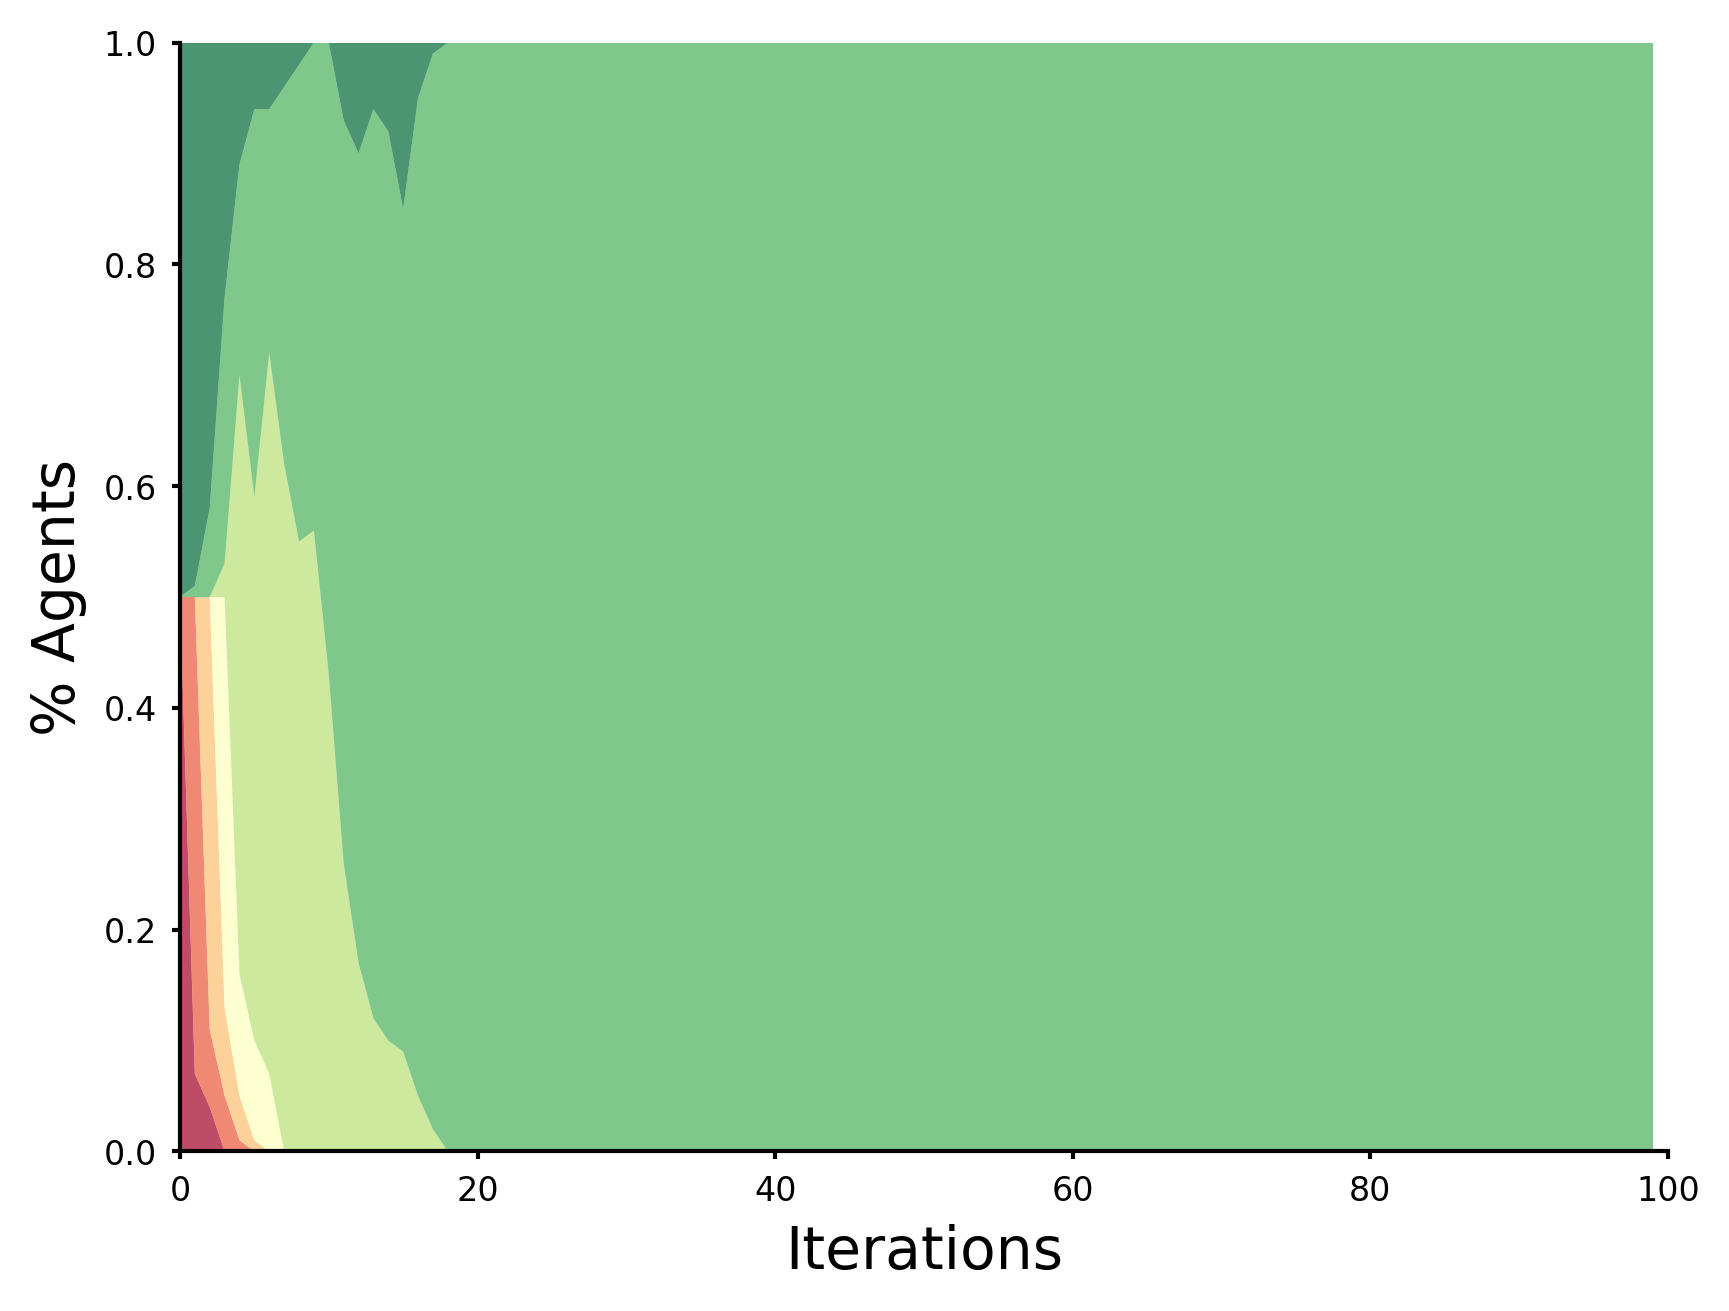

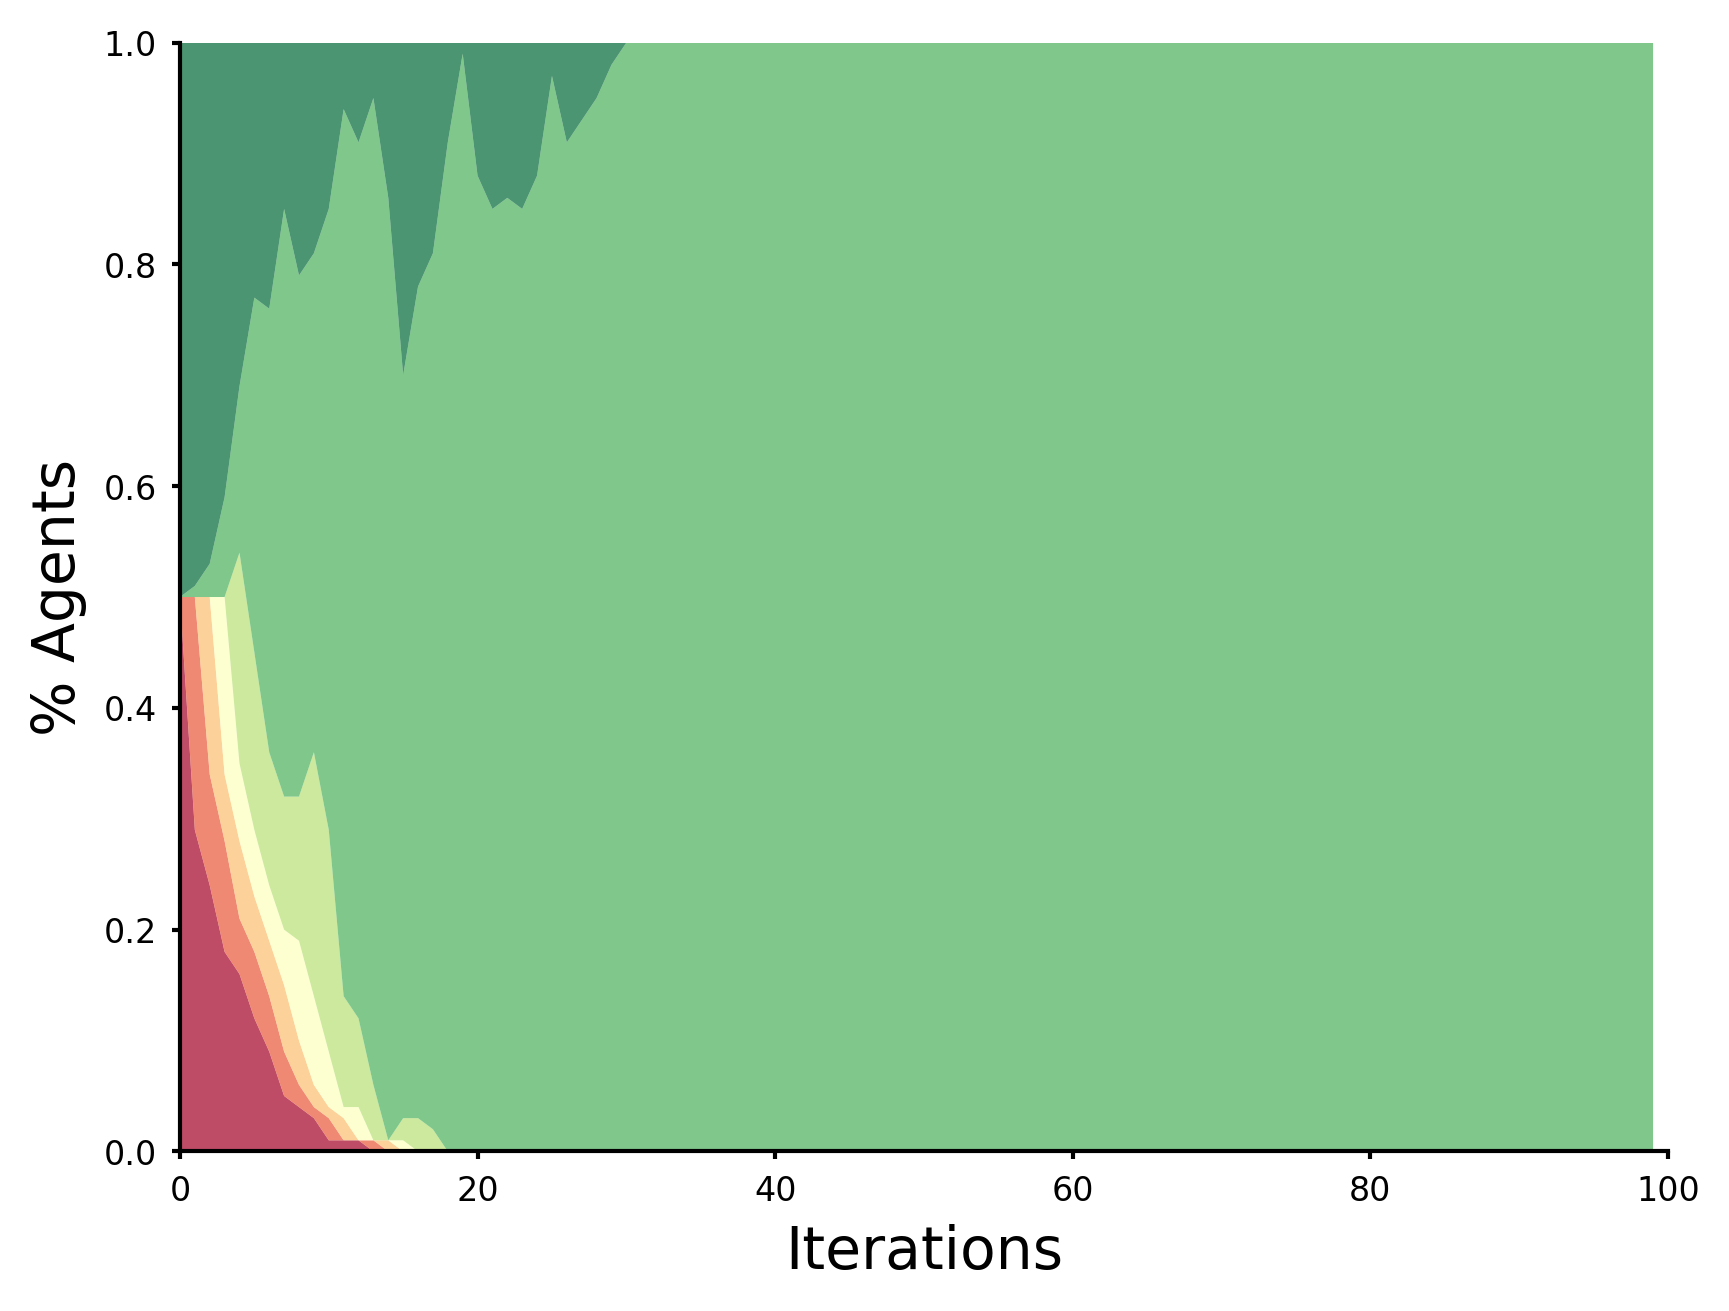

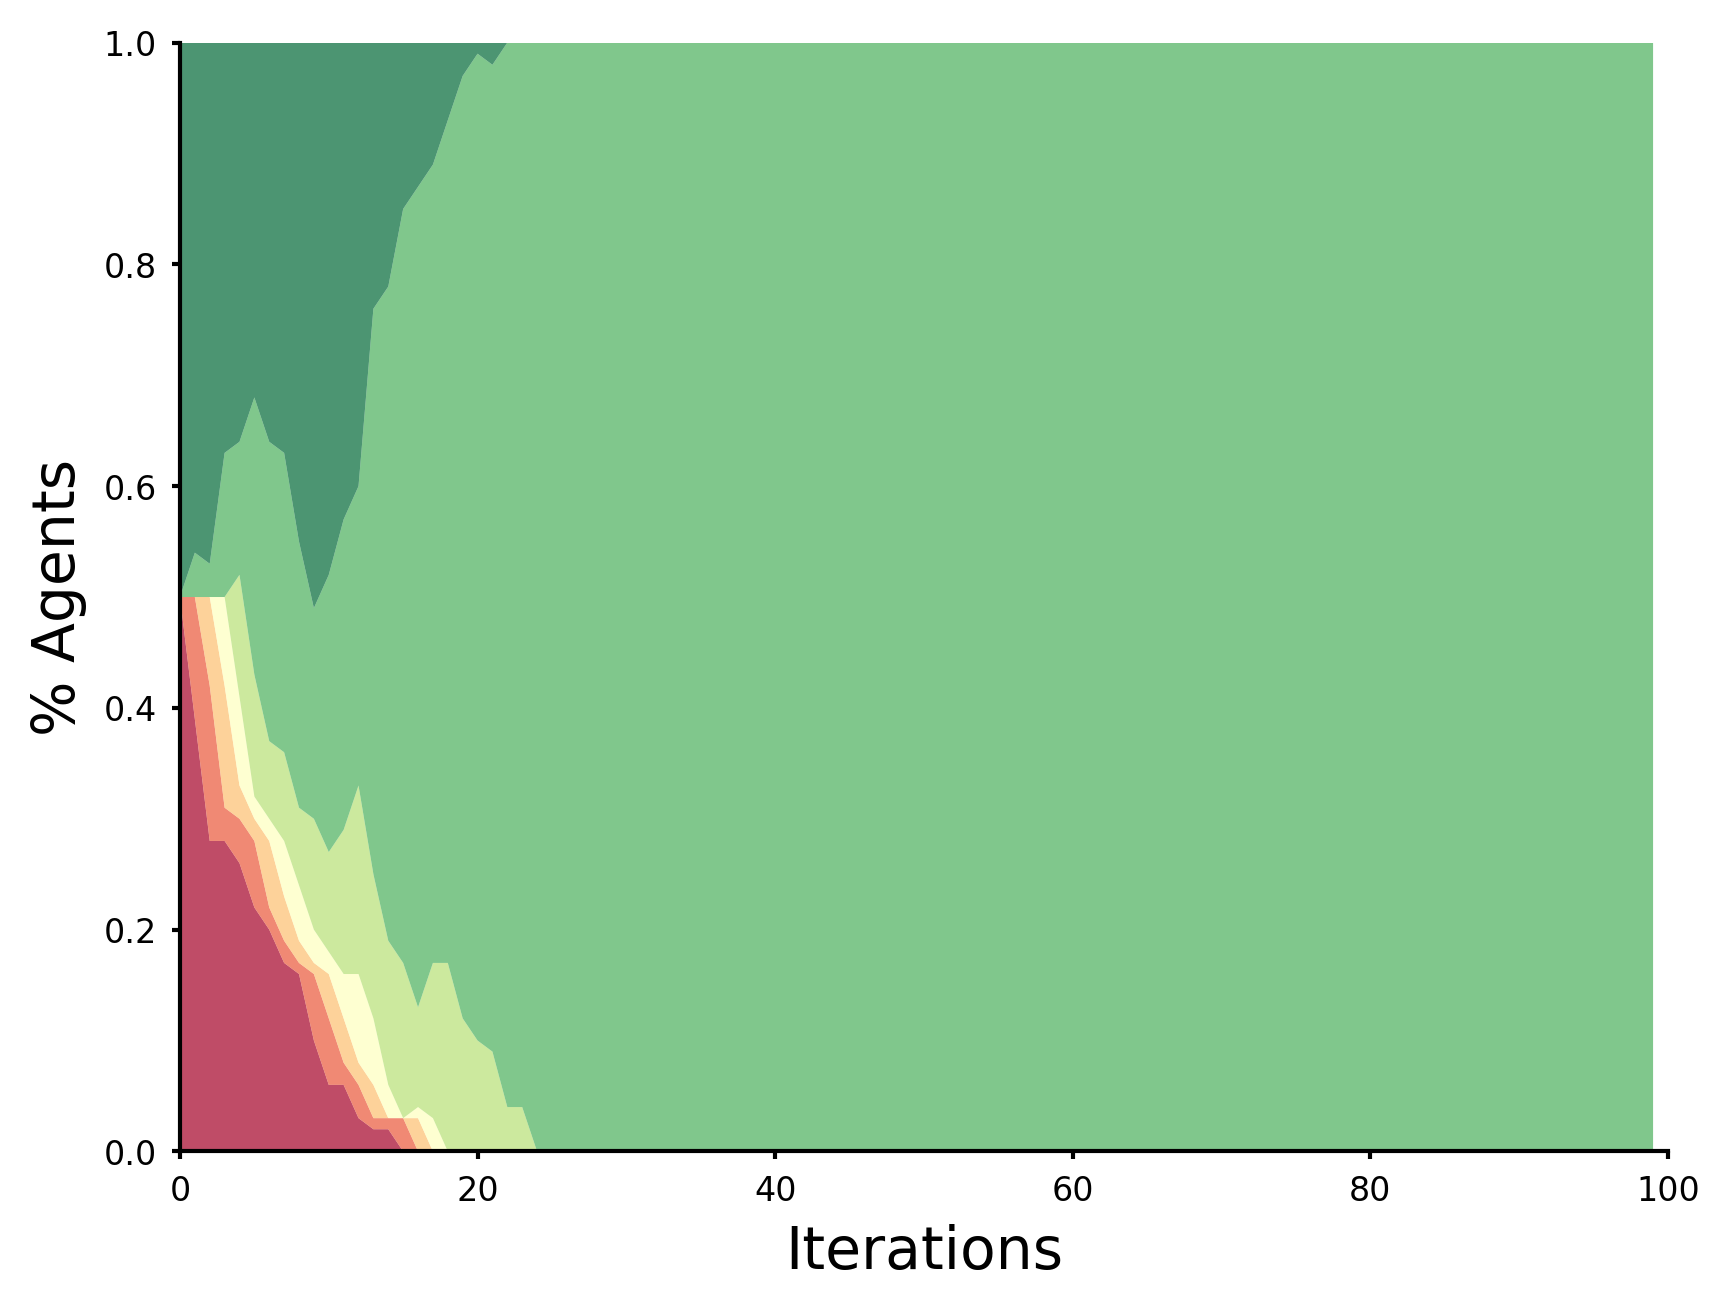

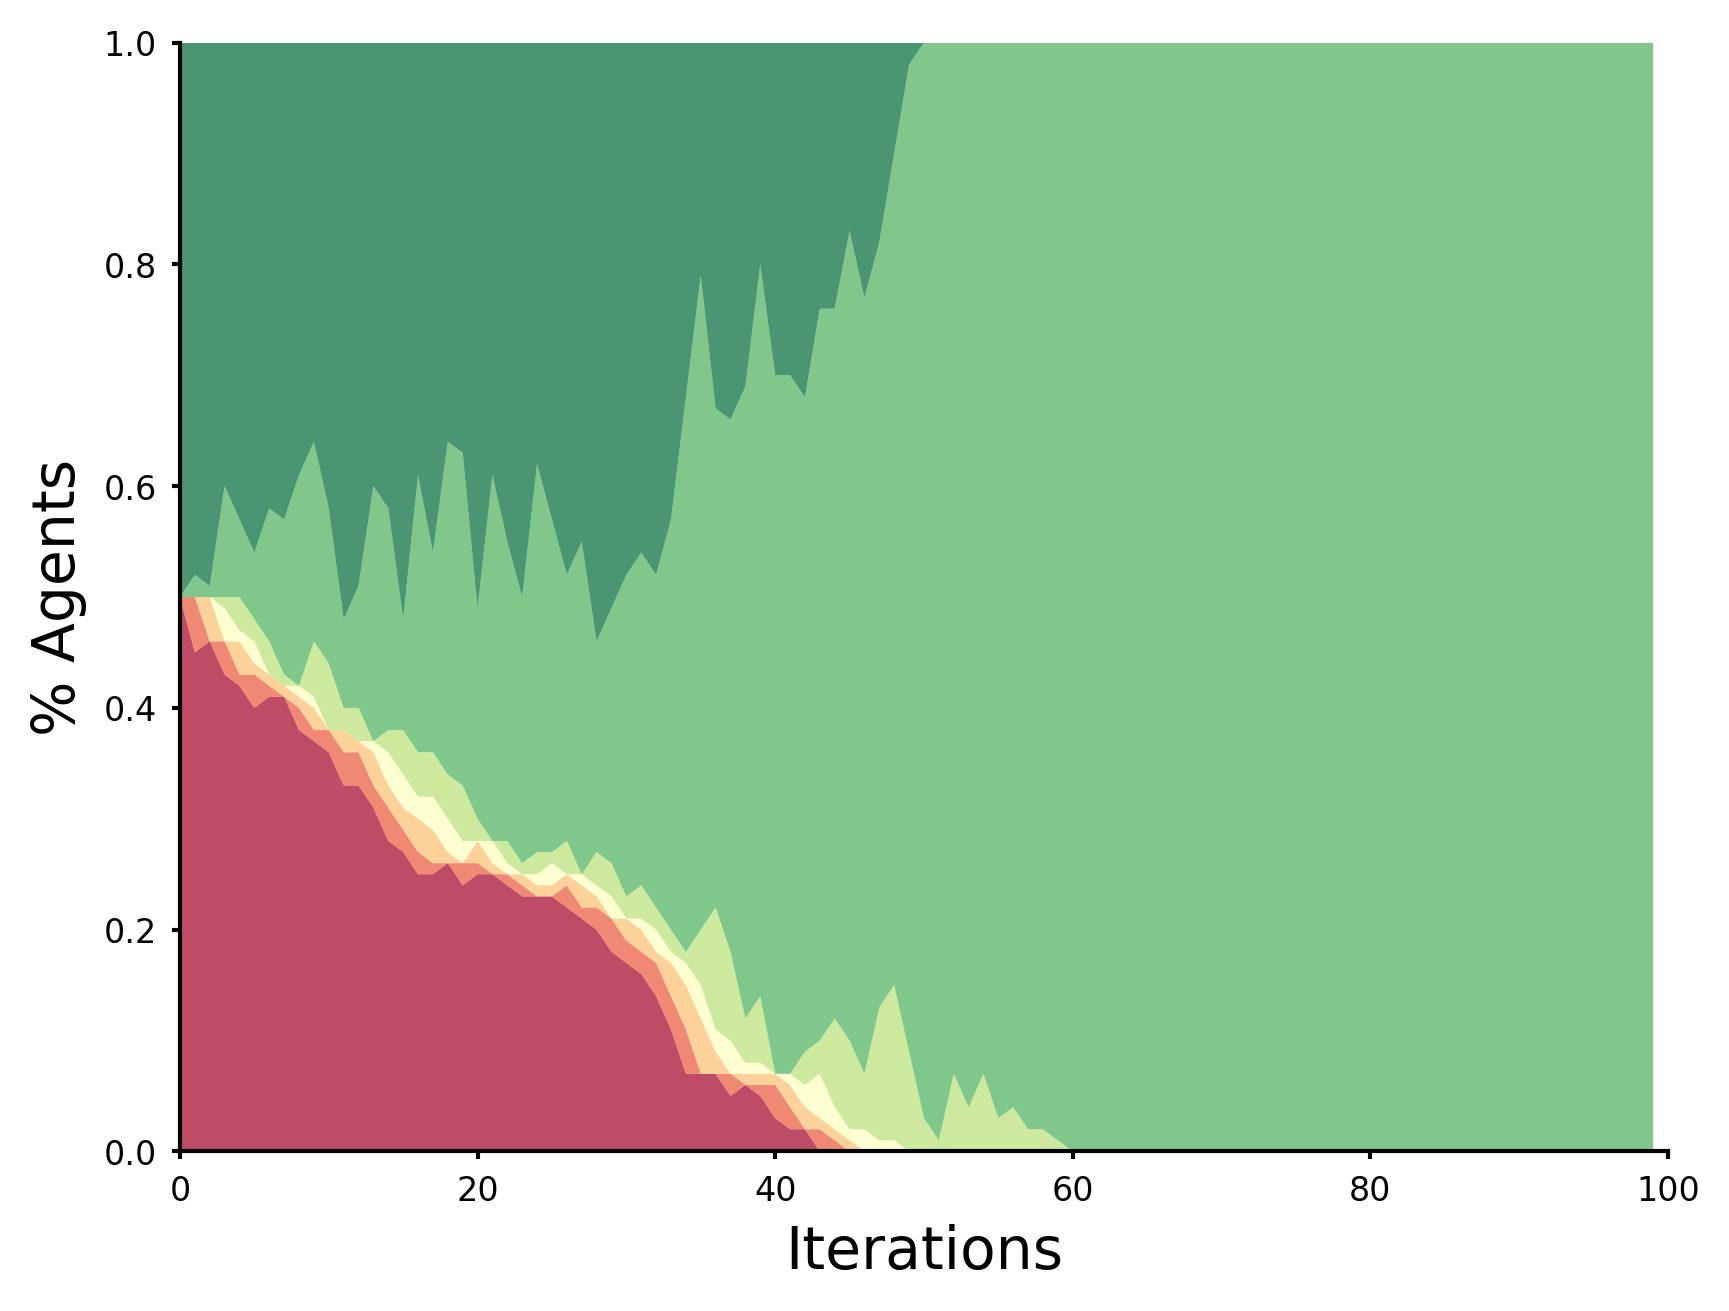

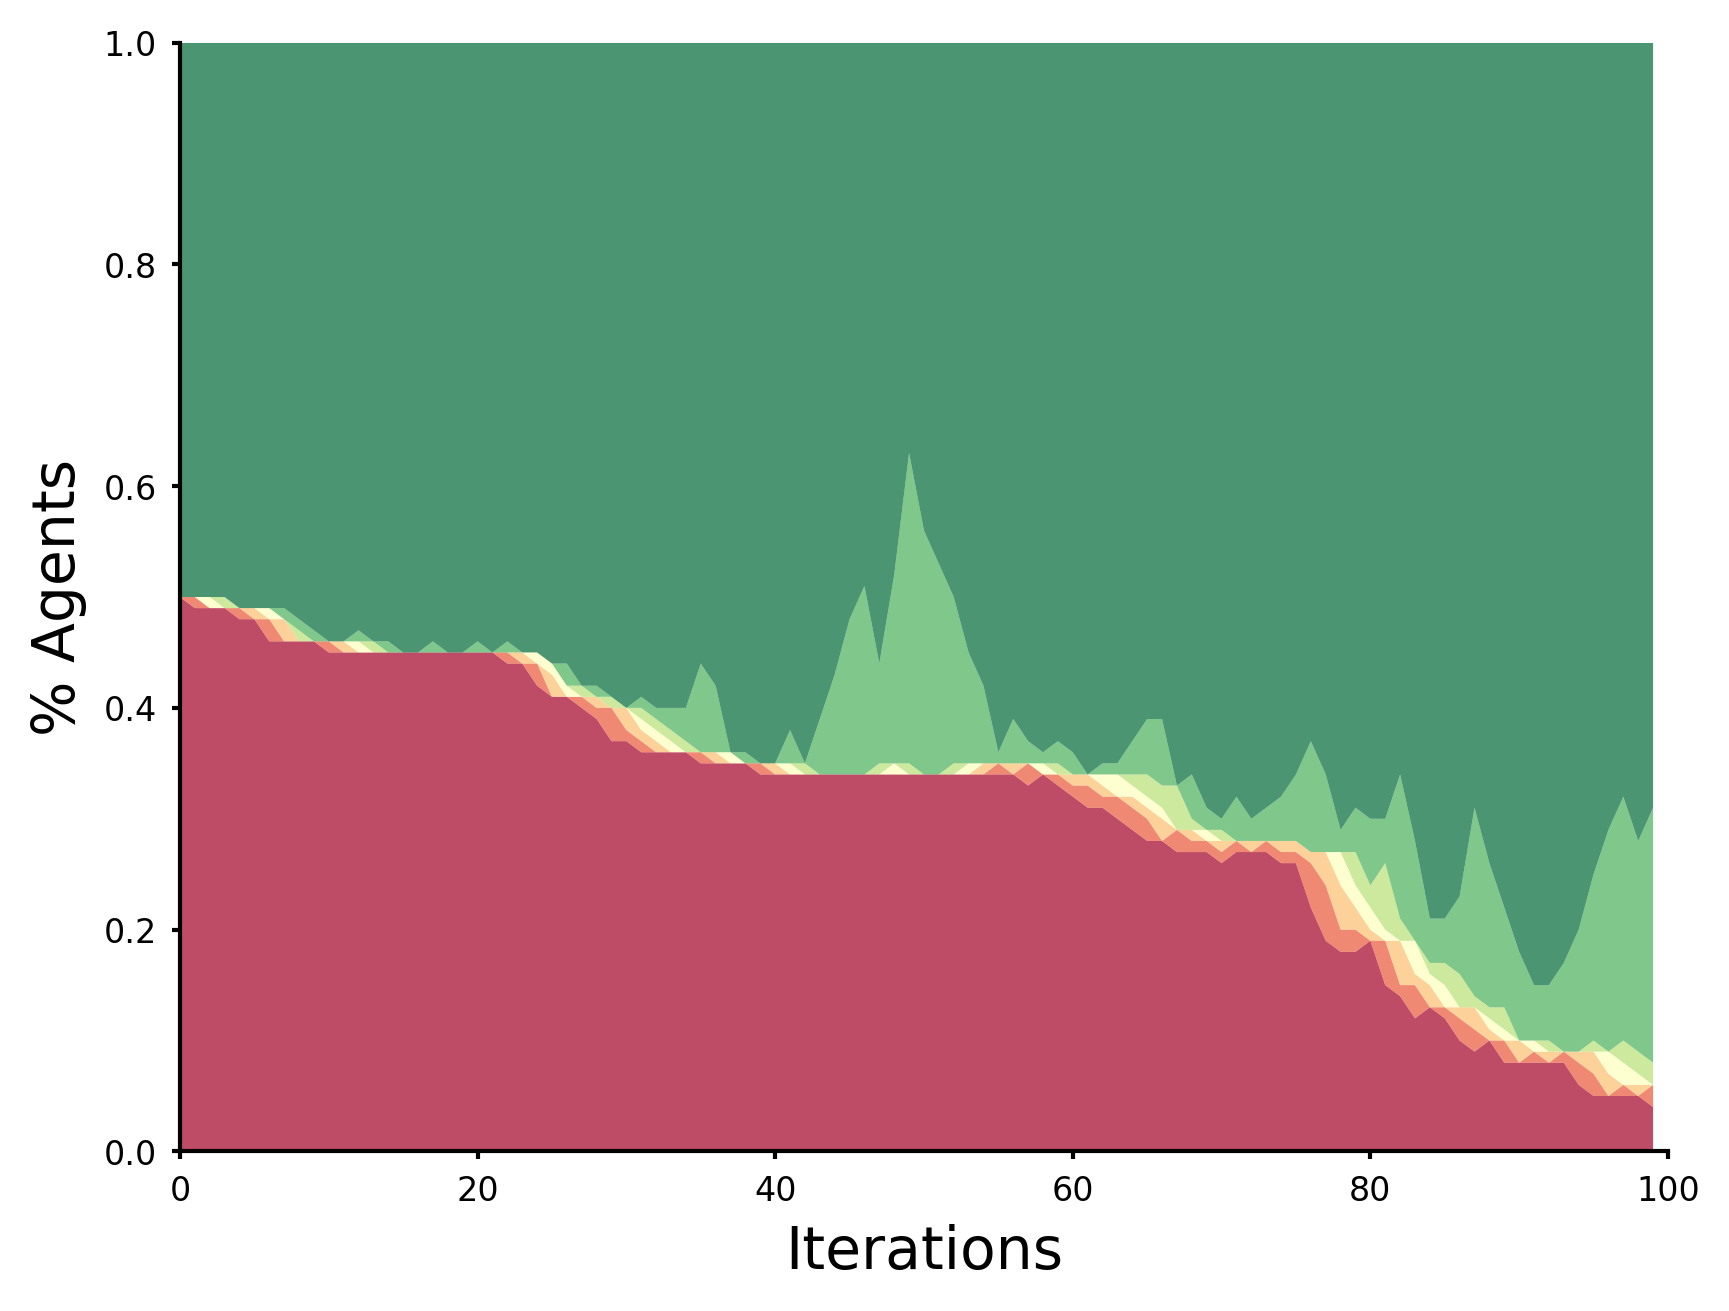

In [4]:
from llm_network.viz import OpinionArea
import os.path

mode = "reverse"

for llm in ['gemma3:4b']:
    for min_size in [0.1, 0.3, 0.5]:
        for h in [0.0, 0.25, 0.5, 0.75, 1.0]:
            filename = f'results/{mode}_theseus_{exp}_{llm}_0_PAH-min{min_size}-h{h}.jsonl'
            if os.path.exists(filename):
                img = OpinionArea(filename)
                img.plot(f"stacked/{mode}_theseus_{exp}_{llm}_0_PAH-min{min_size}-h{h}.png", legend=False)
            else:
                print('not found', filename)




In [5]:
from llm_network.viz import OpinionArea
import os.path
import matplotlib.pyplot as plt
from llm_network.viz.plot_config import apply_plot_config
apply_plot_config()
from matplotlib.patches import Patch

llm = 'gemma3:4b'


# Define the labels and fixed colors (ideally match these with your original palette)
label_order = {
    0: "Strongly Disagree",
    1: "Disagree",
    2: "Mildly Disagree",
    3: "Neutral",
    4: "Mildly Agree",
    5: "Agree",
    6: "Strongly Agree",
}
# Choose the same color map and order used in the OpinionArea class
from matplotlib import cm
import numpy as np
colors = cm.get_cmap('RdYlGn')(np.linspace(0, 1, 7))

# Prepare legend handles
legend_handles = [Patch(facecolor=colors[i], edgecolor='black', label=label_order[i]) for i in range(7)]

for min_size in [0.1, 0.3, 0.5]:
    fig, axs = plt.subplots(1, 5, figsize=(25, 5), sharey=True, facecolor='white')
    h_values = [0.0, 0.25, 0.5, 0.75, 1.0]

    for i, h in enumerate(h_values):
        filename = f'results/{mode}_theseus_{exp}_{llm}_0_PAH-min{min_size}-h{h}.jsonl'
        ax = axs[i]
        ax.set_facecolor('white')

        if os.path.exists(filename):
            print(f"Processing {filename}")
            img = OpinionArea(filename)
            img.plot(ax=ax, legend=False)
            ax.set_title(f"h = {h}", fontsize=14)
        else:
            print("Not found:", filename)
            ax.axis("off")
            ax.set_title(f"h = {h}\n(Missing)", fontsize=12)

    # Add a shared legend below all subplots
    fig.legend(
        handles=legend_handles,
        loc="lower center",
        ncol=7,
        fontsize=20,
        frameon=False,
        bbox_to_anchor=(0.5, -0.05),
    )

    plt.tight_layout(rect=[0, 0.08, 1, 0.95])  # Adjust layout to leave space for the legend
    output_file = f"trends/stacked/{mode}_theseus_{exp}_{llm}_0_PAH-min{min_size}-grid.png"
    plt.savefig(output_file, bbox_inches='tight', facecolor='white')
    plt.close()


/tmp/ipykernel_15942/3216203205.py:24: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  colors = cm.get_cmap('RdYlGn')(np.linspace(0, 1, 7))


Processing results/reverse_theseus_opinion_distr_theseus_same_gemma3:4b_0_PAH-min0.1-h0.0.jsonl
results/reverse_theseus_opinion_distr_theseus_same_gemma3:4b_0_PAH-min0.1-h0.0.jsonl
Processing results/reverse_theseus_opinion_distr_theseus_same_gemma3:4b_0_PAH-min0.1-h0.25.jsonl
results/reverse_theseus_opinion_distr_theseus_same_gemma3:4b_0_PAH-min0.1-h0.25.jsonl
Processing results/reverse_theseus_opinion_distr_theseus_same_gemma3:4b_0_PAH-min0.1-h0.5.jsonl
results/reverse_theseus_opinion_distr_theseus_same_gemma3:4b_0_PAH-min0.1-h0.5.jsonl
Processing results/reverse_theseus_opinion_distr_theseus_same_gemma3:4b_0_PAH-min0.1-h0.75.jsonl
results/reverse_theseus_opinion_distr_theseus_same_gemma3:4b_0_PAH-min0.1-h0.75.jsonl
Processing results/reverse_theseus_opinion_distr_theseus_same_gemma3:4b_0_PAH-min0.1-h1.0.jsonl
results/reverse_theseus_opinion_distr_theseus_same_gemma3:4b_0_PAH-min0.1-h1.0.jsonl
Processing results/reverse_theseus_opinion_distr_theseus_same_gemma3:4b_0_PAH-min0.3-h0.0.j